<a href="https://colab.research.google.com/github/phani-x507/DeepLearning/blob/main/02_Neural_network_Classification_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # 02. Neural Network Classification with Pytorch
 - It is a problem of prediction whether something is onething or another.

## 1. Make classification Data and get it ready


In [100]:
import sklearn

In [101]:
from sklearn.datasets import make_circles

In [102]:
n_samples = 1000

# Create Circles -. X -> matrix features , y-> labels
X, y = make_circles(n_samples,noise = 0.03, random_state = 42)


In [103]:
len(X) , len(y)

(1000, 1000)

In [104]:
print(f"first five samples of X: {X[:5]}")
print(f"first five samples of Y: {y[:5]}")

first five samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first five samples of Y: [1 1 1 1 0]


In [105]:
# From the above there are two labels 0 and one make them binary classification
import pandas as pd
circle_df = pd.DataFrame({"X1":X[:,0], "X2" : X[:,1], "label" : y })
circle_df.head()



,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


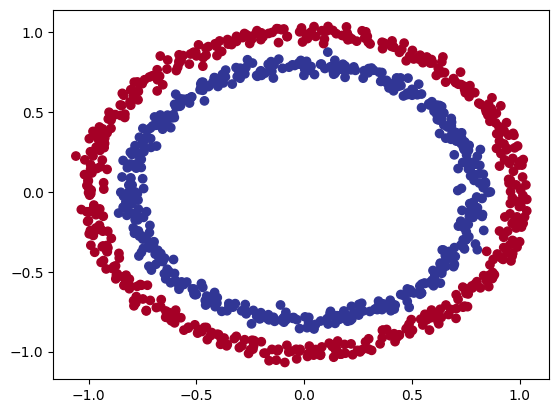

In [106]:
# Visualize, visualize, Visualize
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1], c=y ,cmap = plt.cm.RdYlBu);

# You may find the two circles below red and blue, so there are two classes
# the classes are 0 and 1

Note : The date we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1  Check input and Output Shapes

In [107]:
X.shape , y.shape # X-> 1000 rows and 2 features, y-> 1000 rows and 1 feature

((1000, 2), (1000,))

In [108]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"values of one sample of X:{X_sample} and same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")
# y is a scalar and if doesnt have a shape

values of one sample of X:[0.75424625 0.23148074] and same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [109]:
### 1.2 Turn data into tensors and create train and test Splits

In [110]:
import torch
torch.__version__

'2.10.0+cu128'

In [111]:
import numpy as np
X = np.float32(X)
X = torch.tensor(X)
y = torch.from_numpy(y).type(torch.float)

In [112]:
type(X), X.dtype, y.dtype


(torch.Tensor, torch.float32, torch.float32)

In [113]:
torch.manual_seed(42)



In [114]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [115]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [116]:
n_samples

1000

## 2. Building a model
  Let's build a model to classify our blue and red dot.
  To do so, we want to
  1. Setup Device Agnistic code.
  2. Construct a model (by subclassing `nn.Module`)
  3. Define a loss function and optimizer
  4. Create a trainig and test loop

In [117]:
import torch
from torch import nn


In [118]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [119]:
X_train,

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]]),)

from sklearn import model_selection
We've setup agnistic code.
1. Subclass `nn.Module`
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass and forward computation of the model_selection
4. Instantiate the instance of a model class and send it to the target `device`

In [120]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. create two Linear Layers capable of handling the shapes of our data
    self.layer1 =  nn.Linear(in_features=2, out_features=5) # takes input of two features and upscales it to 5.

    self.layer2 = nn.Linear(in_features=5,out_features=1) #it is Output Layer and input features of this layer should be matched to out_features of previous else may get shape mismatch error. and out_features should be equal to shape of y

    #Linear layer performs xA^t+b operation

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.layer2(self.layer1(x)) # x-> layer_1 -> layer2

# 4. Instantiate the instance of our model class and send it to the target device
model_0 = CircleModelV1().to(device)
model_0


CircleModelV1(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [121]:
device

'cuda'

In [122]:
next(model_0.parameters())

Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188]], device='cuda:0', requires_grad=True)

In [123]:
# Let's Replicate the model about using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features =2 , out_features = 5),
    nn.Linear(in_features=5, out_features=1)

    ).to(device)
model_0


Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [124]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [125]:

untrained_preds = model_0(X_test.to(device))
torch.round(untrained_preds[:10])

tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]], device='cuda:0', grad_fn=<RoundBackward0>)

### 2.1 Setup loss function and optimizer
  - Which loss funtion or optimizer should you use?
  - This is Problem Specific
  - Example - use MAE or MSE for Regression
  - For Classification -> Binary Cross Entropy or Categorical Cross entropy
  - For Optimizers, two most useful are Adam and SG
  - For Loss function we are going to use `torch.nn.BCDWithLogitLoss()`
  - FOr Different Optimizers see `torch.optim` in web.


In [126]:
# Loss function
# loss_fn = nn.BCELoss() -> requires to pass thorugh the sigmoid before using this.
# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss() #Sigmoid activation function builtin

#Optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.1)


In [127]:
#Calculate Accuracy.-  out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true.to(device),y_pred.to(device)).sum().item()

  acc =( correct/len(y_pred))*100

  return acc

In [128]:
### 3.1 Going from raw Logts -> Prediction Probabilities -> Prediction Labels

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [129]:
# Convert logits to Probabilities -> use sigmoid Activation
y_probs = torch.sigmoid(y_logits)
y_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [130]:
# Convert Probabilities to Lables -> suchas classes, whether the point belongs to class 0(inner circle) or class 1(outer cirle)
# Use torch.round() to get rounded values if 0 -> class 0, if 1 class 1
y_labels = torch.round(y_probs)
y_labels

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

In [131]:
# Writing in full ( logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(y_logits.to(device))[:5])

# Check for quality
print(torch.eq(y_labels.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_labels.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [135]:
### 3.2 Building a training and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the no of Epochs
epochs = 200

# Put data to target Device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device),y_test.to(device)

# Build training and Evaluation Loop

for epoch in range(epochs):
  # Training
  model_0.train()

  # Fitting or Forward Pass
  y_logits = model_0(X_train).squeeze()

  y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits -> pred probs -> pred labels

  # Calculate loss and accuracy
  #  if loss_fn -> BCELoss()-> expects prediction probabilities as input, so convert logits -> pred probs using sigmoid activation fn
  loss = loss_fn(y_logits,y_train) # Since we selected BCELossWithLogitsLoss()-> expects logits as parameters

  acc = accuracy_fn(y_true = y_train, y_pred = y_pred)

  #Optimizer
  optimizer.zero_grad()

  #Loss backward (Backprogration)
  loss.backward()

  # Optimizer Step(gradient descent)
  optimizer.step()

  # Evaluate Model
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    #2. Calculate the Test loss / Accuracy
    test_loss = loss_fn(test_logits.squeeze(),y_test)
    test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

  if epoch %10 == 0:
    print(f'Epoch : {epoch} | Loss : {loss:.5f} | Acc : {acc:.2f}% | Test loss: {test_loss:.5f} | Test Accuracy : {test_acc:.2f}')


Epoch : 0 | Loss : 0.69301 | Acc : 51.25% | Test loss: 0.69404 | Test Accuracy : 47.50
Epoch : 10 | Loss : 0.69301 | Acc : 51.62% | Test loss: 0.69406 | Test Accuracy : 47.00
Epoch : 20 | Loss : 0.69300 | Acc : 51.62% | Test loss: 0.69408 | Test Accuracy : 47.50
Epoch : 30 | Loss : 0.69300 | Acc : 51.25% | Test loss: 0.69410 | Test Accuracy : 47.50
Epoch : 40 | Loss : 0.69300 | Acc : 51.00% | Test loss: 0.69412 | Test Accuracy : 47.50
Epoch : 50 | Loss : 0.69300 | Acc : 50.88% | Test loss: 0.69414 | Test Accuracy : 47.00
Epoch : 60 | Loss : 0.69300 | Acc : 51.00% | Test loss: 0.69416 | Test Accuracy : 47.00
Epoch : 70 | Loss : 0.69300 | Acc : 51.00% | Test loss: 0.69418 | Test Accuracy : 47.00
Epoch : 80 | Loss : 0.69300 | Acc : 51.00% | Test loss: 0.69420 | Test Accuracy : 47.00
Epoch : 90 | Loss : 0.69299 | Acc : 51.12% | Test loss: 0.69421 | Test Accuracy : 47.00
Epoch : 100 | Loss : 0.69299 | Acc : 50.88% | Test loss: 0.69423 | Test Accuracy : 47.00
Epoch : 110 | Loss : 0.69299 | A

## 4. Make Predictions and evaluate the model,
- From the metrics it looks like our model isn't learning anything.
- So to inspect it let's make some predictions and make them visual



In [137]:
import requests
from pathlib import Path


if Path("helper_functions.py").is_file():
  print("The file already exists")

else:
  print("Downloading Helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)



In [139]:
from helper_functions import plot_predictions,plot_decision_boundary

[]

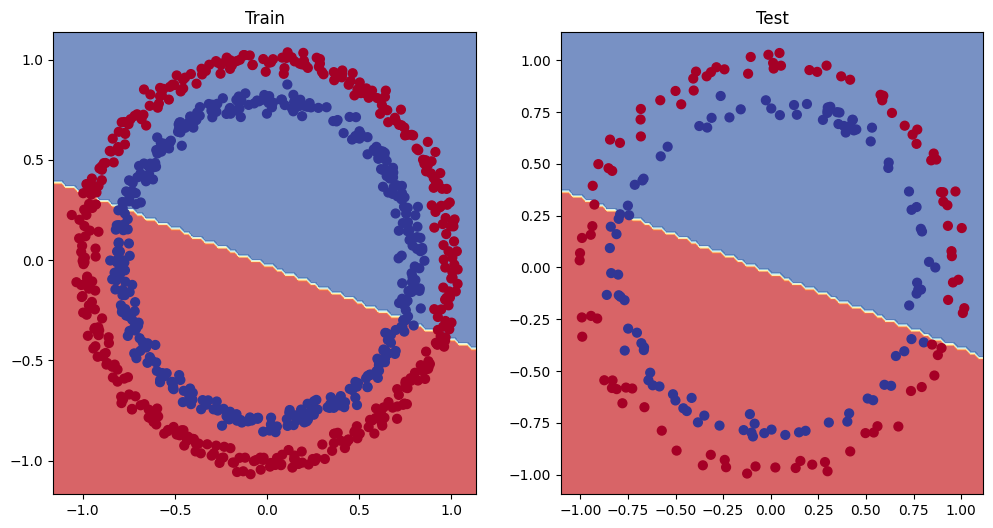

In [147]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

plt.plot()